# GDEX Capacity-Weighted Solar Factor

This is an isolated research-only notebook. It reads the completed 2016–2026 GDEX solar history and local evaluation artifacts without modifying the production panel or any GCS object. Every result preserves the current strategy convention: capacity-weighted wind, `sig_observed_weather=0`, `sig_cpc_level=0`, a one-session signal lag, a front-month switch five trading sessions before official LTD, and a 2.5 bps position-turnover cost.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = next(
    candidate for candidate in (Path.cwd(), *Path.cwd().parents)
    if (candidate / 'naturalgas').is_dir()
)
RESULTS_ROOT = PROJECT_ROOT / 'results/experiments/solar'
GENERATED_ROOT = PROJECT_ROOT / 'naturalgas/processed/ncar_gdex_complete_solar_factor'
summary = json.loads((RESULTS_ROOT / 'summary.json').read_text())
annual = pd.read_csv(RESULTS_ROOT / 'solar_selected_annual.csv')
ic = pd.read_csv(RESULTS_ROOT / 'solar_factor_ic.csv')
costs = pd.read_csv(RESULTS_ROOT / 'solar_cost_sensitivity.csv')
grid_path = GENERATED_ROOT / 'solar_weight_grid.csv'
daily_path = GENERATED_ROOT / 'solar_selected_daily.parquet'
grid = pd.read_csv(grid_path) if grid_path.exists() else None
daily = pd.read_parquet(daily_path) if daily_path.exists() else None
if daily is not None:
    daily['date'] = pd.to_datetime(daily['date'])
if grid is None or daily is None:
    print(
        'Optional grid/equity cells are skipped unless generated with: '
        'python naturalgas/evaluate_ncar_gdex_complete_solar_factor.py'
    )
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
print(f"Sample: {summary['sample_start'][:10]} -> {summary['sample_end'][:10]} | {summary['trading_days']:,} sessions")

Sample: 2016-07-06 -> 2026-07-13 | 2,515 sessions


## Factor definition

For each GFS issue, forecast days 1–5, and 28 sample locations:

$$PVAvailability_t = \frac{\sum_i Capacity_{i,t-2m} \cdot (SW_i / SW^{extra}_i) \cdot TempEfficiency_i}{\sum_i Capacity_{i,t-2m}}$$

$$SolarFactor_t = DaylightScale_t \cdot \tanh\left(\frac{Z^{causal}_{60}(-PVAvailability_t)}{2}\right)$$

A positive value indicates abnormally low expected solar availability over days 1–5 and therefore greater expected gas-fired generation. Installed capacity comes from EIA utility-scale SUN data, mapped from plant coordinates to the nearest weather location and lagged two months. `DaylightScale` uses deterministic extraterrestrial horizontal radiation to reduce the nominal impact of a one-standard-deviation winter anomaly. The solar allocation is funded from the current fundamental weight.

In [2]:
coverage = pd.Series({
    'GDEX monthly partitions': 127,
    'complete solar trading days': summary['solar_complete_trading_days'],
    'missing/incomplete trading days': summary['solar_missing_or_incomplete_trading_days'],
    'capacity history through': '2026-05',
    'latest mapped utility solar MW': 162_301,
    'selected wind shoulder weight': summary['selected_upstream_wind_allocation']['shoulder_wind'],
}, name='value')
display(coverage.to_frame())

,value
GDEX monthly partitions,127
complete solar trading days,2511
missing/incomplete trading days,4
capacity history through,2026-05
latest mapped utility solar MW,162301
selected wind shoulder weight,0.2250


## Core results

`baseline` is the current wind strategy after removing observed weather and CPC level. The 5% version is conservative; 10% is the intermediate version examined most closely; `neutral` removes the same fundamental weight while fixing the solar signal at zero, distinguishing genuine signal value from simply reducing fundamentals. The 15% development optimum lies at the upper search boundary and is retained only as a sensitivity.

In [3]:
period_order = ['development', 'validation', 'first_look_holdout', 'full']
if grid is None:
    print('Skipped weight-grid tables: optional generated solar_weight_grid.csv is absent.')
else:
    rows = []
    specs = [
        ('baseline', 'baseline', 'baseline', 0.0),
        ('solar 5% active', 'pv_daylight', 'active', 0.05),
        ('solar 5% neutral', 'pv_daylight', 'neutral', 0.05),
        ('solar 10% active', 'pv_daylight', 'active', 0.10),
        ('solar 10% neutral', 'pv_daylight', 'neutral', 0.10),
        ('solar 15% active', 'pv_daylight', 'active', 0.15),
    ]
    for label, factor, variant, weight in specs:
        q = grid[(grid.factor == factor) & (grid.variant == variant) & np.isclose(grid.nominal_weight, weight)]
        for row in q.itertuples():
            rows.append({'version': label, 'period': row.period, 'Sharpe': row.sharpe_zero_rf, 'CAGR': row.cagr, 'MDD': row.maximum_drawdown, 'win_rate': row.win_rate})
    core = pd.DataFrame(rows)
    display(core.pivot(index='version', columns='period', values='Sharpe').reindex(columns=period_order).round(4))
    display(core[core.period == 'full'].set_index('version')[['Sharpe', 'CAGR', 'MDD', 'win_rate']].round(4))

period,development,validation,first_look_holdout,full
version,,,,
baseline,1.1974,1.5507,1.0623,1.2754
solar 10% active,1.3423,1.6413,1.2407,1.4057
solar 10% neutral,1.2476,1.5908,1.1124,1.3198
solar 15% active,1.3722,1.6253,1.2798,1.4193
solar 5% active,1.2838,1.6182,1.1681,1.3583
solar 5% neutral,1.2245,1.5717,1.0883,1.2990


,Sharpe,CAGR,MDD,win_rate
version,,,,
baseline,1.2754,0.0924,-0.0586,0.5249
solar 5% active,1.3583,0.0985,-0.0555,0.5217
solar 5% neutral,1.2990,0.0909,-0.0591,0.5209
solar 10% active,1.4057,0.1044,-0.0558,0.5229
solar 10% neutral,1.3198,0.0894,-0.0596,0.5177
solar 15% active,1.4193,0.1100,-0.0568,0.5225


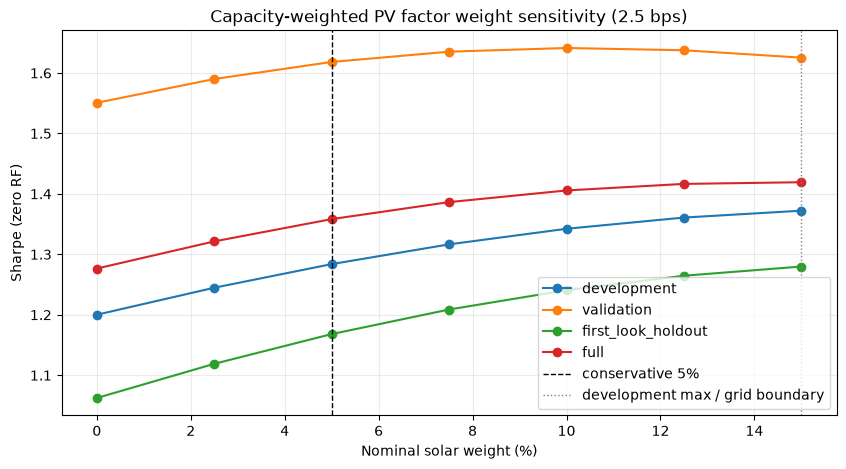

In [4]:
if grid is None:
    print('Skipped weight-sensitivity plot: optional generated solar_weight_grid.csv is absent.')
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    active = grid[(grid.factor == 'pv_daylight') & (grid.variant == 'active')]
    for period in period_order:
        q = active[active.period == period].sort_values('nominal_weight')
        ax.plot(100*q.nominal_weight, q.sharpe_zero_rf, marker='o', label=period)
    ax.axvline(5, color='black', ls='--', lw=1, label='conservative 5%')
    ax.axvline(15, color='gray', ls=':', lw=1, label='development max / grid boundary')
    ax.set(title='Capacity-weighted PV factor weight sensitivity (2.5 bps)', xlabel='Nominal solar weight (%)', ylabel='Sharpe (zero RF)')
    ax.grid(alpha=.25); ax.legend(); plt.show()

## Radiation versus cloud cover

The physical definitions are compared at the same 5% nominal weight. `pv_daylight` is the primary version; `pv_fixed` omits daylight scaling; `radiation_daylight` omits temperature efficiency; and `cloud_daylight` uses total cloud cover alone. IC is the Spearman correlation between the issue-day signal and the next trading session's NG return.

In [5]:
if grid is None:
    print('Skipped physical-factor comparison: optional generated solar_weight_grid.csv is absent.')
else:
    factor_5 = grid[(grid.variant == 'active') & np.isclose(grid.nominal_weight, .05) & (grid.factor != 'baseline')]
    display(factor_5.pivot(index='factor', columns='period', values='sharpe_zero_rf').reindex(columns=period_order).round(4))
display(ic.pivot(index='factor', columns='period', values='spearman_ic').reindex(columns=period_order).round(4))

period,development,validation,first_look_holdout,full
factor,,,,
cloud_daylight,1.2703,1.5857,1.0713,1.3157
pv_daylight,1.2838,1.6182,1.1681,1.3583
pv_fixed,1.2971,1.6442,1.1924,1.3771
radiation_daylight,1.3000,1.5824,1.1846,1.3559


period,development,validation,first_look_holdout,full
factor,,,,
cloud_daylight,0.0192,0.0235,0.0148,0.0212
pv_daylight,0.0252,0.0458,0.0619,0.0435
pv_fixed,0.0215,0.0466,0.0642,0.0430
radiation_daylight,0.0247,0.0232,0.0727,0.0385


## Cost sensitivity and annual stability

cost_bps,0.0000,2.5000,5.0000
variant,,,
baseline,1.3304,1.2754,1.2203
solar_active_conservative,1.4146,1.3583,1.3019
solar_active_development_selected,1.4783,1.4193,1.3603
solar_active_intermediate,1.4634,1.4057,1.3479


variant,baseline,neutral_slot_intermediate,solar_active_intermediate,solar_minus_baseline,solar_minus_neutral
year,,,,,
2016,0.6080,0.5370,0.7300,0.1210,0.1930
2017,0.1590,0.2480,0.1340,-0.0250,-0.1140
2018,-0.2230,-0.2470,-0.3690,-0.1460,-0.1220
2019,2.3970,2.5090,2.3600,-0.0370,-0.1490
2020,1.9710,2.0350,2.4450,0.4740,0.4100
2021,1.6260,1.5550,1.6600,0.0350,0.1050
2022,2.3580,2.4560,2.4500,0.0920,-0.0050
2023,0.3900,0.4630,0.5930,0.2030,0.1300
2024,1.9200,2.0520,2.3540,0.4340,0.3020


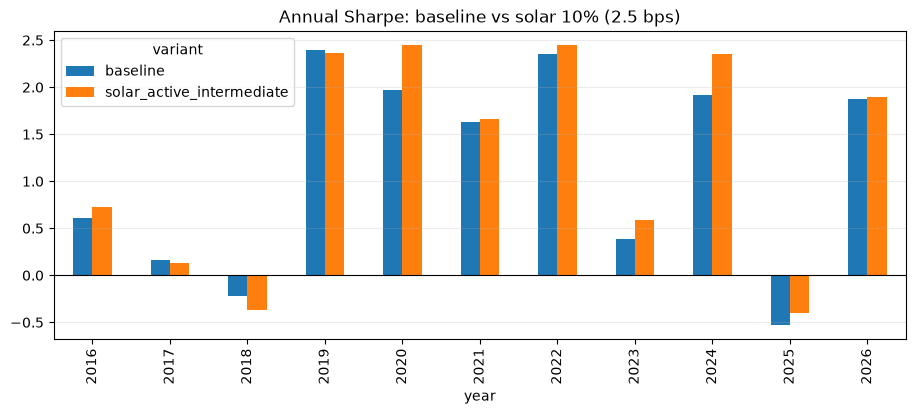

In [6]:
display(costs.pivot(index='variant', columns='cost_bps', values='sharpe_zero_rf').round(4))
ann = annual[annual.variant.isin(['baseline', 'solar_active_intermediate', 'neutral_slot_intermediate'])]
ann_sharpe = ann.pivot(index='year', columns='variant', values='sharpe_zero_rf')
ann_sharpe['solar_minus_baseline'] = ann_sharpe['solar_active_intermediate'] - ann_sharpe['baseline']
ann_sharpe['solar_minus_neutral'] = ann_sharpe['solar_active_intermediate'] - ann_sharpe['neutral_slot_intermediate']
display(ann_sharpe.round(3))
ax = ann_sharpe[['baseline', 'solar_active_intermediate']].plot(kind='bar', figsize=(11, 4), title='Annual Sharpe: baseline vs solar 10% (2.5 bps)')
ax.axhline(0, color='black', lw=.8); ax.grid(axis='y', alpha=.25); plt.show()

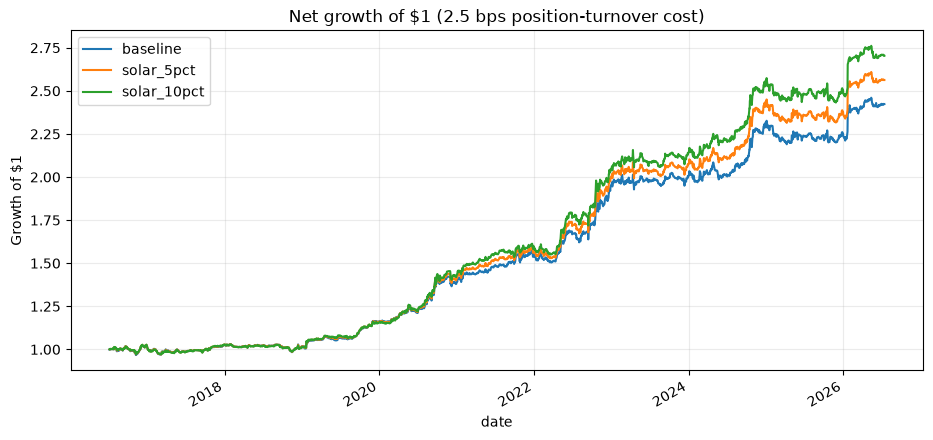

In [7]:
if daily is None:
    print('Skipped equity plot: optional generated solar_selected_daily.parquet is absent.')
else:
    def net_return(position):
        turnover = position.diff().abs().fillna(position.abs())
        return position * daily.roll_adjusted_return - turnover * 2.5 / 10_000
    equity = pd.DataFrame({
        'date': daily.date,
        'baseline': (1 + net_return(daily.position_baseline)).cumprod(),
        'solar_5pct': (1 + net_return(daily['position_active_pv_daylight_0.050'])).cumprod(),
        'solar_10pct': (1 + net_return(daily['position_active_pv_daylight_0.100'])).cumprod(),
    }).set_index('date')
    ax = equity.plot(figsize=(11, 5), title='Net growth of $1 (2.5 bps position-turnover cost)')
    ax.set_ylabel('Growth of $1'); ax.grid(alpha=.25); plt.show()

## Research judgment

- The physically constrained 5% version improves Sharpe in development, validation, and 2024+, and adds value relative to the neutral slot. It deserves further research.
- The 10% version outperforms 5% in development, validation, and 2024+ without reaching the grid boundary, making it a more defensible intermediate research setting than 15%.
- However, 10% was confirmed after viewing validation and the first-look holdout. The 5% version remains the more conservative control, and 10% requires new forward evidence.
- Win rate does not rise; improvement comes mainly from return magnitude and tail path rather than more profitable days.
- The cloud-only version fails relative to its neutral slot in 2024+, supporting shortwave radiation/PV availability over total cloud cover as the solar condition variable.
- This is not a complete PV generation model: distributed capacity, panel orientation/tracking, snow, curtailment, and availability are absent. The conclusion is to continue research, not deploy directly.